## <b> BAIT 508 GROUP PROJECT</b>  
<b> B A 2    |   G R O U P   27</b>  

<b>TEAM MEMBERS  -  STUDENT ID</b>  
Role description
  
  
- Thao Do - 33849365  
Thao studied the data and implemented the analysis coding across all project components and worked on the project report for Part 1 and 3
  
  
- Koko Deng - 18735712  
Koko studied the data and implemented the analysis coding for Part 1 and 2, and worked on the report for Part 2 and 3


### <b>1A. Industry Sector Selection and Data Filtering</b>  
  
&nbsp;&nbsp;&nbsp;&nbsp; 1. Selected industry: Transportation By Air (group code: 45)  
&nbsp;&nbsp;&nbsp;&nbsp; 2. We then filtered out fiscal year data from companies within this sector in the "data/public_firms.csv" file  
&nbsp;&nbsp;&nbsp;&nbsp; 3. Please find the answers below:    
  
- Nb. unique firm-year ("fyear") observations are there in the filtered dataset: 27  
- Nb. unique firms are there in the filtered dataset: 111  
- Nb. in the filtered dataset have records over all 27 years (1994-2020): 4   

In [1]:
import pandas as pd

df = pd.read_csv('public_firms.csv', index_col=None)
def starts_with_45(x):
    return str(x).startswith("45")

#2 filter "public_firms.csv" data to only include the firms belonging to the chosen sector
company_data = df[df["sic"].apply(starts_with_45)]      

#3 answer questions

print("Number of unique firm-year observations in the filtered data set: " + str(len(company_data["fyear"].value_counts())))

print("Number of unique firm-year observations in the filtered data set: " + str(len(company_data["conm"].value_counts())))

print("Number of firms in the filtered dataset have records over all 27 years (1994-2020): " + str(len(company_data["conm"].value_counts()[company_data["conm"].value_counts() == 27])))


Number of unique firm-year observations in the filtered data set: 27
Number of unique firm-year observations in the filtered data set: 111
Number of firms in the filtered dataset have records over all 27 years (1994-2020): 4


<b> Citation:</b>  
W3Schools. (2025). Python String startswith() Method. https://www.w3schools.com/python/ref_string_startswith.asp

### <b>1B. Preliminary analysis  </b>


In [ ]:
#1. Top 10 firms with highest stock price in 2020

top_10_stock_2020 = company_data[company_data["fyear"] == 2020].sort_values("prcc_c", ascending=False).head(10)
print("top 10 firms with the highest stock price in 2020 are: " + str(top_10_stock_2020[["conm", "prcc_c"]]))

top 10 firms with the highest stock price in 2020 are:                                 conm  prcc_c
14369                     FEDEX CORP  259.62
190505           ALLEGIANT TRAVEL CO  189.24
169375   GRUPO AEROPORTUARIO SURESTE  164.93
188222  GRUPO AEROPORTUARIO DEL PACI  111.29
138511          RYANAIR HOLDINGS PLC  109.98
187501              COPA HOLDINGS SA   77.23
119487  ATLAS AIR WORLDWIDE HLDG INC   54.54
900             ALASKA AIR GROUP INC   52.00
191794  GRUPO AEROPORTUARIO DEL CENT   51.68
36248             SOUTHWEST AIRLINES   46.61


In [2]:
#2. Top 10 firms with highest sales in the entire history of the data set

Top_10_historical_sales = company_data.sort_values('sale', ascending=False).head(10)
print("Top 10 firms with the highest sales in the entire history of the data set are: " + str(Top_10_historical_sales[['conm','sale', 'fyear']]))


Top 10 firms with the highest sales in the entire history of the data set are:                               conm     sale  fyear
14369                   FEDEX CORP  83959.0   2020
14367                   FEDEX CORP  69693.0   2018
14368                   FEDEX CORP  69217.0   2019
14366                   FEDEX CORP  65450.0   2017
14365                   FEDEX CORP  60319.0   2016
14364                   FEDEX CORP  50365.0   2015
14363                   FEDEX CORP  47453.0   2014
11301          DELTA AIR LINES INC  47007.0   2019
142    AMERICAN AIRLINES GROUP INC  45768.0   2019
1441         AMERICAN AIRLINES INC  45761.0   2019


In [4]:
#3. Geographical distribution of the firms

print("Geographical distribution of Transporation by Air firms: ")
loc_distribution = company_data.groupby("location")["conm"].value_counts()
unique_loc = loc_distribution.groupby(level=0).count().sort_values(ascending=False)
unique_loc

Geographical distribution of Transporation by Air firms: 


location
USA    87
MEX     4
BRA     3
CHN     2
COL     1
CYM     1
DEU     1
ESP     1
FRA     1
CAN     1
IRL     1
ISR     1
JOR     1
JPN     1
LUX     1
CHL     1
NLD     1
PAN     1
GBR     1
Name: count, dtype: int64

In [163]:
help(pd.DataFrame.groupby)

Help on function groupby in module pandas.core.frame:

groupby(self, by=None, axis: 'Axis | lib.NoDefault' = <no_default>, level: 'IndexLabel | None' = None, as_index: 'bool' = True, sort: 'bool' = True, group_keys: 'bool' = True, observed: 'bool | lib.NoDefault' = <no_default>, dropna: 'bool' = True) -> 'DataFrameGroupBy'
    Group DataFrame using a mapper or by a Series of columns.
    
    A groupby operation involves some combination of splitting the
    object, applying a function, and combining the results. This can be
    used to group large amounts of data and compute operations on these
    groups.
    
    Parameters
    ----------
    by : mapping, function, label, pd.Grouper or list of such
        Used to determine the groups for the groupby.
        If ``by`` is a function, it's called on each value of the object's
        index. If a dict or Series is passed, the Series or dict VALUES
        will be used to determine the groups (the Series' values are first
        alig

<b> Citation:</b>

- Here we applied the groupby() function learned in class to find the number of firms per location. <br> 
- As the data set repeats companies by rows, grouping the data by both location and company name and then using value_counts() would overcount.  
- Thanks to the examples in the help() function, we learned that you can group by different levels of a hierarchical index.  
- In  our case, grouping the data by the [0] index (location) then counting gives us the precise number of unique firms.


In [115]:
print("Top 10 locations with the highest number of firms are: ")
print(unique_loc.head(10))

Top 10 locations with the highest number of firms are: 
location
USA    87
MEX     4
BRA     3
CHN     2
COL     1
CYM     1
DEU     1
ESP     1
FRA     1
CAN     1
Name: count, dtype: int64


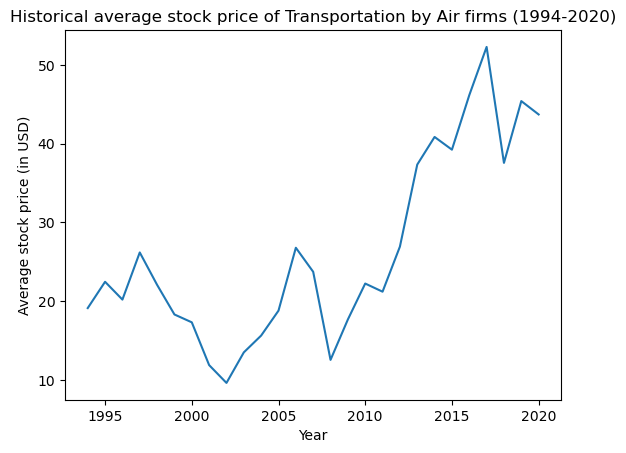

In [181]:
#4. Create a line chart to show the average stock price (column "prcc_c") in the selected sector(s) across the years

import matplotlib.pyplot as plt

ave_stock = company_data.groupby("fyear")["prcc_c"].mean()
ave_stock.plot(y=['prcc_c'], x=['fyear'], kind="line")
plt.ylabel('Average stock price (in USD)')
plt.xlabel('Year')

plt.title('Historical average stock price of Transportation by Air firms (1994-2020)')
plt.show()




In [7]:
#5. Which firm was affected the most by the 2008 Financial Crisis, as measured by the percentage drop in stock price from 2007 to 2008?

# filter for companies with stock price in 2007 and 2008
stock_2007 = company_data[company_data["fyear"] == 2007][["conm", "prcc_c"]]
stock_2008 = company_data[company_data["fyear"] == 2008][["conm", "prcc_c"]]

# create an empty list to store the results
result = []

for x in stock_2007["conm"]:
    if x in stock_2008["conm"].values:
        price_08 = stock_2008[stock_2008["conm"] == x]["prcc_c"].values[0]
        price_07 = stock_2007[stock_2007["conm"] == x]["prcc_c"].values[0]
        percent_drop =  round((price_08 - price_07)/ price_07 * 100, 2)
        result.append((x, percent_drop))

df_result = pd.DataFrame(result, columns=["company", "percent drop"])
df_sorted = df_result.sort_values("percent drop", ascending=True)

print("Top 10 firms most affected by the 2008 Financial Crisis are: ")
print(df_sorted.head(10))            

print("")
print("Frontier Airlines Holdings was the firm affected the most by the 2008 Financial Crisis, \n with an almost 97-percent decline in stock price between 2007 and 2008")



Top 10 firms most affected by the 2008 Financial Crisis are: 
                         company  percent drop
21    FRONTIER AIRLINES HOLDINGS        -96.58
39  AIR TRANSPORT SERVICES GROUP        -95.69
14            MESA AIR GROUP INC        -91.67
41   MACQUARIE INFRASTR HOLD LLC        -90.70
37        PINNACLE AIRLINES CORP        -88.85
50       CHINA SOUTHERN AIRLINES        -87.03
42                  AVANTAIR INC        -85.85
26   CHINA EASTERN AIRLINES CORP        -84.33
31   SAKER AVIATION SERVICES INC        -84.21
40  GOL LINHAS AEREAS INTELIGENT        -82.96

Frontier Airlines Holdings was the firm affected the most by the 2008 Financial Crisis, 
 with an almost 97-percent decline in stock price between 2007 and 2008


<b> Citation 1:</b>
 
- <b>Name, version, company of AI tool:</b> Chat GPT-5 mini.
- <b>Chat objective:</b> to debug code
- <b>Use of AI-generated content:</b>   
  
<b> Evaluation of Results:</b> Chat GPT correctly identified the issue, which was because I was doing arithmetic on pandas Series, not real numbers. <br> Hence, when I tried to perform the subtraction of stock prices between 2007 and 2008, Python tried to match these row indexes first. <br>For unmatched cases, it cannot do the subtraction and makes the result empty. <br> That is why we need to apply another way to extract the numbers from the series before doing calculation and ChatGPT suggested adding the .values attribute.   

<b> Limitations:</b>  none 
    
 <b> How I used the AI’s response:</b> I added the .values attribute where applicable and the list result finally returned with numerical values.  
- URL of chat history: https://chatgpt.com/share/68e02510-ce3c-8009-aef2-5a553079ff42
- Time and date of chat: Oct 3 12:30 pm

<b> Citation 2:</b>  
We learned how to use the pd.DataFrame function in class to convert a dictionary to data frame format. In the code above, we also apllied this methodology to form a new data frame table from a new calculated result, including the definition of new column names. This is learned by consulting the help function, with regards to pd.DataFrame:

In [213]:
help(pd.DataFrame)

Help on class DataFrame in module pandas.core.frame:

class DataFrame(pandas.core.generic.NDFrame, pandas.core.arraylike.OpsMixin)
 |  DataFrame(data=None, index: 'Axes | None' = None, columns: 'Axes | None' = None, dtype: 'Dtype | None' = None, copy: 'bool | None' = None) -> 'None'
 |  
 |  Two-dimensional, size-mutable, potentially heterogeneous tabular data.
 |  
 |  Data structure also contains labeled axes (rows and columns).
 |  Arithmetic operations align on both row and column labels. Can be
 |  thought of as a dict-like container for Series objects. The primary
 |  pandas data structure.
 |  
 |  Parameters
 |  ----------
 |  data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
 |      Dict can contain Series, arrays, constants, dataclass or list-like objects. If
 |      data is a dict, column order follows insertion-order. If a dict contains Series
 |      which have an index defined, it is aligned by its index. This alignment also
 |      occurs if data i

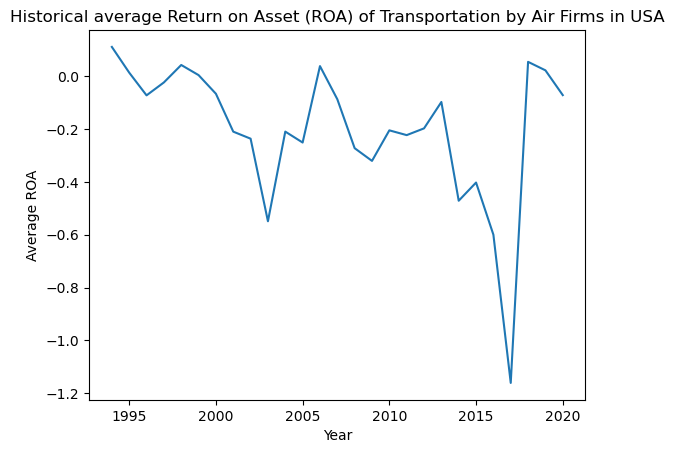

In [183]:
#6. Plot the average Return on Assets (ROA) for the firms located in the “USA” across the years. ROA is calculated as ni/asset.

import matplotlib.pyplot as plt

usa_data = company_data[company_data["location"] == "USA"]
roa_by_year_usa = usa_data.groupby("fyear")["roa"].mean()
roa_by_year_usa.plot(y=['roa'], x=['fyear'], kind="line")
plt.ylabel('Average ROA')
plt.xlabel('Year')

plt.title('Historical average Return on Asset (ROA) of Transportation by Air Firms in USA')
plt.show()


### <b>2. Text analysis on the industry sector</b>

In [122]:
dff = pd.read_csv('2020_10K_item1_full.csv', encoding = 'utf-8')
dff['item_1_text']

0       fixed expenses are previosuly documented in an...
1       General Hurco Companies, Inc. is an internatio...
2       We have been engaged in the business of develo...
3       CORPORATE HISTORY Chun Can Capital Group (form...
4       CORPORATE HISTORY Chun Can Capital Group (form...
                              ...                        
5476    General RF Industries, Ltd. (together with sub...
5477    BACKGROUND AND CAPITAL STRUCTURE Know Labs, In...
5478    General GEE Group Inc. (the  Company ,  us ,  ...
5479    General GulfSlope Energy, Inc. is an independe...
5480    (a) General Development of Business. North Eur...
Name: item_1_text, Length: 5481, dtype: object

In [123]:
# download nltk
!pip3 install nltk

import nltk
import string

<b>2C: Load the dataset as a DataFrame and create a new column containing the cleaned text for each “item_1” content.</b>   
  
&nbsp;&nbsp;&nbsp;&nbsp; 1. Convert all words into lowercase.  
&nbsp;&nbsp;&nbsp;&nbsp; 2. Remove punctuations.  
&nbsp;&nbsp;&nbsp;&nbsp; 3. Remove stop words based on the list of English stop words in NLTK.  


In [124]:
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

translator = str.maketrans('', '', string.punctuation)
sw = stopwords.words('english')

def clean_text(text):
    ''' This function cleans a string input and 
        returns a version with: lower-case, no punctuations, and no stopwords
    '''
    text_lower = text.lower() # make it lowercase
    text_no_punctuation = text_lower.translate(translator) # remove punctuation  
    clean_words = [w for w in text_no_punctuation.split() if w not in sw] # remove stopwords
    return ' '.join(clean_words)

dff['text1_clean'] = dff['item_1_text'].apply(clean_text)

print(dff['text1_clean'])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thaodo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0       fixed expenses previosuly documented 8k 235000...
1       general hurco companies inc international indu...
2       engaged business developing marketing products...
3       corporate history chun capital group formerly ...
4       corporate history chun capital group formerly ...
                              ...                        
5476    general rf industries ltd together subsidiarie...
5477    background capital structure know labs inc inc...
5478    general gee group inc company us incorporated ...
5479    general gulfslope energy inc independent crude...
5480    general development business north european oi...
Name: text1_clean, Length: 5481, dtype: object


<b>2D: Conduct keywords analysis on your selected industry sector(s).</b>   
  
&nbsp;&nbsp;&nbsp;&nbsp; 1. Create a new DataFrame that includes only firms in your selected industry sector(s).   
&nbsp;&nbsp;&nbsp;&nbsp; Ensure that you merge the 10-K data with the previous "public_firm.csv" data using an inner join.
    
&nbsp;&nbsp;&nbsp;&nbsp; 2. Generate the top 10 keywords for each firm based on two different methods: word counts and TF-IDF score  
   
&nbsp;&nbsp;&nbsp;&nbsp; 3. Create two wordclouds to visualize the keywords across all firms in the selected sector(s):  
&nbsp;&nbsp;&nbsp;&nbsp; one based on the word counts and another based on the TF-IDF scores.    

In [125]:
# existing companies with SIC code starting with "45" from public_firms.csv
company_data

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
118,1045,1995,USA,AMERICAN AIRLINES GROUP INC,NaN,4512,74.250,82.000,167.000,19556.000,16910.000,0.008540
119,1045,1996,USA,AMERICAN AIRLINES GROUP INC,NaN,4512,88.125,68.000,1016.000,20497.000,17753.000,0.049568
120,1045,1997,USA,AMERICAN AIRLINES GROUP INC,NaN,4512,128.500,64.000,985.000,20915.000,18570.000,0.047095
121,1045,1998,USA,AMERICAN AIRLINES GROUP INC,NaN,4512,59.375,95.000,1314.000,22303.000,19205.000,0.058916
122,1045,1999,USA,AMERICAN AIRLINES GROUP INC,NaN,4512,67.000,85.000,985.000,24374.000,17730.000,0.040412
...,...,...,...,...,...,...,...,...,...,...,...,...
208962,298636,2016,COL,AVIANCA HOLDINGS SA,NaN,4512,9.640,375.753,16.980,6351.335,4138.338,0.002673
208963,298636,2017,COL,AVIANCA HOLDINGS SA,NaN,4512,8.030,508.982,48.523,6861.396,4441.684,0.007072
208964,298636,2018,COL,AVIANCA HOLDINGS SA,NaN,4512,4.060,273.108,-24.803,7118.643,4890.830,-0.003484
208965,298636,2019,COL,AVIANCA HOLDINGS SA,NaN,4512,4.460,342.472,-913.712,7273.910,4614.975,-0.125615


<b> Duplications found:</b>  
- We found 3 duplicative rows in the 2020_10K_item1_full.csv sharing the same item 1 text entries for ERA GROUP INC.  
- According to the public_firms.csv source of truth, ERA’s gvkey value should be 187766. 
- However, one of the three rows has a gvkey value of  '8092', which actually belongs to BRISTOW GROUP INC. This could happen due to the fact that BRISTOW GROUP INC <br> completed a merger with ERA GROUP INC. in 2020, so the two companies' gvkey codes may have been used interchangeably (Bristow Group Inc., 2020).  


As a rsult, we chose to remove:  
- Row index [2357] as its gvkey value does not match the record in public_firms.csv to ensure consistency by retaining only the record with gvkey '187766' for ERA GROUP INC.  
- Row index [2358] to remove redundancy.


In [179]:
#check for duplications

dff[dff['gvkey'].isin([8092, 187766])]


,cik,year,name,item_1_text,gvkey,text1_clean
2357,1525221,2020,ERA GROUP INC.,"Unless the context indicates otherwise, the te...",8092,unless context indicates otherwise terms us co...
2358,1525221,2020,ERA GROUP INC.,"Unless the context indicates otherwise, the te...",187766,unless context indicates otherwise terms us co...
2359,1525221,2020,ERA GROUP INC.,"Unless the context indicates otherwise, the te...",187766,unless context indicates otherwise terms us co...


<b> Citation </b>  
W3Schools. (2025). Pandas DataFrame isin() Method
https://www.w3schools.com/python/pandas/ref_df_isin.asp


In [128]:
#remove duplicated rows

dff_c = dff.drop(dff.index[[2357, 2358]])
dff_c


,cik,year,name,item_1_text,gvkey,text1_clean
0,1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119,fixed expenses previosuly documented 8k 235000...
1,315374,2020,HURCO COMPANIES INC,"General Hurco Companies, Inc. is an internatio...",5788,general hurco companies inc international indu...
2,1622996,2020,"ACRO BIOMEDICAL CO., LTD.",We have been engaged in the business of develo...,27584,engaged business developing marketing products...
3,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614,corporate history chun capital group formerly ...
4,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614,corporate history chun capital group formerly ...
...,...,...,...,...,...,...
5476,740664,2020,R F INDUSTRIES LTD,"General RF Industries, Ltd. (together with sub...",2829,general rf industries ltd together subsidiarie...
5477,1074828,2020,"KNOW LABS, INC.","BACKGROUND AND CAPITAL STRUCTURE Know Labs, In...",166430,background capital structure know labs inc inc...
5478,40570,2020,GEE Group Inc.,"General GEE Group Inc. (the Company , us , ...",5050,general gee group inc company us incorporated ...
5479,1341726,2020,"GULFSLOPE ENERGY, INC.","General GulfSlope Energy, Inc. is an independe...",175595,general gulfslope energy inc independent crude...


<b> Citation: </b>  
W3Schools. (2025). Pandas DataFrame drop() Method. https://www.w3schools.com/python/pandas/ref_df_drop.asp

In [ ]:
# Part D1. Create a new DataFrame that includes only firms in your selected industry sector(s). 
# Ensure that you merge the 10-K data with the previous "public_firm.csv" data using an inner join.

merged_df = dff_c.merge(company_data, left_on = "gvkey", right_on = "gvkey", how = "inner")
merged_df

,cik,year,name,item_1_text,gvkey,text1_clean,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
0,92380,2020,SOUTHWEST AIRLINES CO,Company Overview Southwest Airlines Co. (the ...,9882,company overview southwest airlines co company...,1995,USA,SOUTHWEST AIRLINES,NaN,4512,23.0000,317.363,182.626,3256.122,2872.751,0.056087
1,92380,2020,SOUTHWEST AIRLINES CO,Company Overview Southwest Airlines Co. (the ...,9882,company overview southwest airlines co company...,1996,USA,SOUTHWEST AIRLINES,NaN,4512,22.0000,581.841,207.337,3723.479,3406.170,0.055684
2,92380,2020,SOUTHWEST AIRLINES CO,Company Overview Southwest Airlines Co. (the ...,9882,company overview southwest airlines co company...,1997,USA,SOUTHWEST AIRLINES,NaN,4512,24.6250,623.343,317.772,4246.160,3816.821,0.074838
3,92380,2020,SOUTHWEST AIRLINES CO,Company Overview Southwest Airlines Co. (the ...,9882,company overview southwest airlines co company...,1998,USA,SOUTHWEST AIRLINES,NaN,4512,22.6875,378.511,433.431,4715.996,4163.980,0.091907
4,92380,2020,SOUTHWEST AIRLINES CO,Company Overview Southwest Airlines Co. (the ...,9882,company overview southwest airlines co company...,1999,USA,SOUTHWEST AIRLINES,NaN,4512,16.1250,418.819,474.378,5652.113,4735.587,0.083929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,1048911,2020,FEDEX CORP,Overview FedEx Corporation ( FedEx ) was incor...,4598,overview fedex corporation fedex incorporated ...,2016,USA,FEDEX CORP,NaN,4513,186.2000,3969.000,2997.000,48552.000,60319.000,0.061728
375,1048911,2020,FEDEX CORP,Overview FedEx Corporation ( FedEx ) was incor...,4598,overview fedex corporation fedex incorporated ...,2017,USA,FEDEX CORP,NaN,4513,249.5400,3265.000,4572.000,52330.000,65450.000,0.087369
376,1048911,2020,FEDEX CORP,Overview FedEx Corporation ( FedEx ) was incor...,4598,overview fedex corporation fedex incorporated ...,2018,USA,FEDEX CORP,NaN,4513,161.3300,2319.000,540.000,54403.000,69693.000,0.009926
377,1048911,2020,FEDEX CORP,Overview FedEx Corporation ( FedEx ) was incor...,4598,overview fedex corporation fedex incorporated ...,2019,USA,FEDEX CORP,NaN,4513,151.2100,4881.000,1286.000,73537.000,69217.000,0.017488


<b> Citation: </b>  

W3Schools. (2025). Pandas merge method. W3Schools.https://www.w3schools.com/python/pandas/ref_df_merge.asp

In [ ]:
# Generate Top 10 keywords for each firm based on: word counts

from collections import Counter

def get_top_keywords(text):
    topten = text.split()
    c = Counter(topten)
    list = c.most_common(10)
    keywords = []
    for word in list:
        keywords.append(word[0])
    return ' '.join(keywords)

merged_df['top_10_keywords_wordcounts'] = merged_df['text1_clean'].apply(get_top_keywords)
print(merged_df[['conm', 'top_10_keywords_wordcounts']])

                   conm                         top_10_keywords_wordcounts
0    SOUTHWEST AIRLINES  company southwest aircraft flight also service...
1    SOUTHWEST AIRLINES  company southwest aircraft flight also service...
2    SOUTHWEST AIRLINES  company southwest aircraft flight also service...
3    SOUTHWEST AIRLINES  company southwest aircraft flight also service...
4    SOUTHWEST AIRLINES  company southwest aircraft flight also service...
..                  ...                                                ...
374          FEDEX CORP  fedex express us service services freight grou...
375          FEDEX CORP  fedex express us service services freight grou...
376          FEDEX CORP  fedex express us service services freight grou...
377          FEDEX CORP  fedex express us service services freight grou...
378          FEDEX CORP  fedex express us service services freight grou...

[379 rows x 2 columns]


In [ ]:
# Generate Top 10 keywords for each firm based on: TF-IDF score  

!pip3 install scikit-learn

from sklearn.feature_extraction.text import TfidfVectorizer

def get_keywords_tfidf(document_list):
    '''
    This function gets a list of documents as input and returns a list of top 10 keywords for each document using TF-IDF scores.
    Input: A list of documents (text)
    Output: The corresponding top 10 keywords for each document based on tf-idf values
    '''
    vectorizer = TfidfVectorizer() # Step 1: Create a TF-IDF vectorizer
    tfidf_matrix = vectorizer.fit_transform(document_list) # Step 2: Calculate the TF-IDF matrix
    feature_names = vectorizer.get_feature_names_out() # Step 3: Get feature names (words)

    # Step 4: Extract top 10 keywords for each document
    top_keywords = [] # accumulator
    for i in range(len(document_list)):
        feature_index = tfidf_matrix[i, :].nonzero()[1]
        feature_value = [tfidf_matrix[i, x] for x in feature_index]
        tfidf_scores = zip(feature_index, feature_value)
        sorted_tfidf_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
        top_keywords.append(' '.join([feature_names[i] for i, _ in sorted_tfidf_scores[:10]]))

        if i % 200 == 199:
            print(f'Processed {i+1}/{len(document_list)} documents.')
    
    return top_keywords

docs = merged_df['text1_clean'].tolist()
len(docs)

# Training the docs to get TD-IDF scores
tfidf_keywords = get_keywords_tfidf(docs)

# Add a new column in the dataframe
merged_df['top_keyword_tfidf'] = tfidf_keywords

Processed 200/379 documents.


In [132]:
# check what tfidf_keywords contain.
print(type(tfidf_keywords))
print(len(tfidf_keywords))

# see TFIDF keywords
tfidf_keywords

<class 'list'>
379


['company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flight also airline alist max service',
 'company southwest fare aircraft flig

In [ ]:
#part D2. check 2 new columns for top 10 keywords
merged_unique = merged_df.groupby('name').head(1)
print(merged_unique)
print(merged_unique.shape)

# save the merged WordCount/TFIDF result to a new csv file
merged_unique.to_csv(r"2020_10K_item1_full_tfidf11.csv", index = None, encoding = 'utf-8')

         cik  year                                name  \
0      92380  2020               SOUTHWEST AIRLINES CO   
26   1498710  2020               Spirit Airlines, Inc.   
38   1172222  2020               HAWAIIAN HOLDINGS INC   
64    766421  2020              ALASKA AIR GROUP, INC.   
90     27904  2020               DELTA AIR LINES, INC.   
116  1158463  2020                JETBLUE AIRWAYS CORP   
137   793733  2020                         SKYWEST INC   
164     4515  2020             AMERICAN AIRLINES, INC.   
190  1135185  2020    ATLAS AIR WORLDWIDE HOLDINGS INC   
215   319687  2020               UNITED AIRLINES, INC.   
241  1362468  2020                 Allegiant Travel CO   
257   894081  2020  Air Transport Services Group, Inc.   
277  1525221  2020                      ERA GROUP INC.   
287  1128281  2020       Saker Aviation Services, Inc.   
305   353184  2020                           AIR T INC   
332   899394  2020            HARBOR DIVERSIFIED, INC.   
352  1048911  

In [134]:
conda install -c conda-forge wordcloud

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 25.9.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


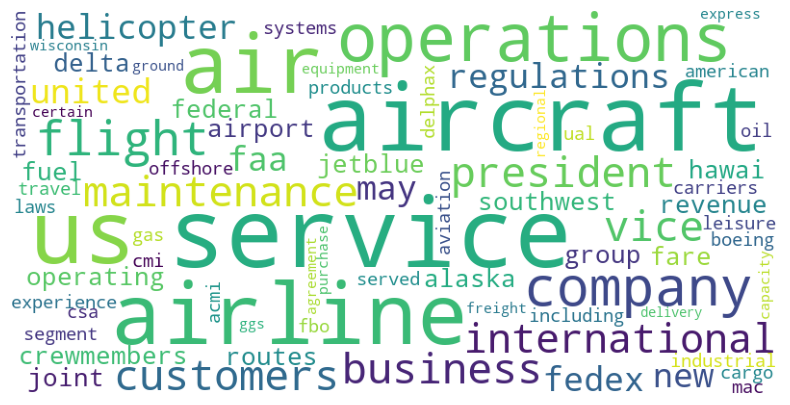

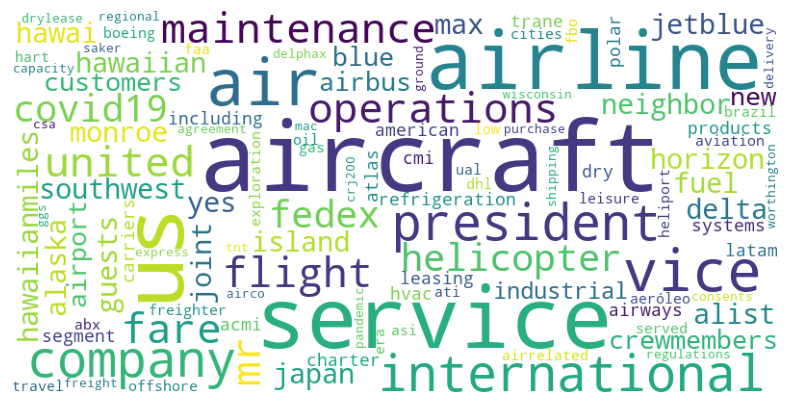

In [ ]:
# Part D3. Create two wordclouds to visualize the keywords across all firms in the selected sector(s):  
# one based on the word counts and another based on the TF-IDF scores.


from wordcloud import WordCloud
import matplotlib.pyplot as plt

# prepare text
text_wordcounts = ' '.join(merged_unique['top_10_keywords_wordcounts'].tolist())
text_tfidf = ' '.join(merged_unique['top_keyword_tfidf'].tolist())

# return result: wordcounts method
wordcloud1 = WordCloud(width=800, height=400, max_font_size=100, background_color='white').generate(text_wordcounts) # note that text is a string, not a list

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud1)
plt.savefig('keyword_wordcounts.png') # save as PNG file
plt.show()

# return result: TFIDF method
wordcloud2 = WordCloud(width=800, height=400, max_font_size=100, background_color='white').generate(text_tfidf) # note that text is a string, not a list
plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud2)
plt.savefig('keyword_tfidf.png') # save as PNG file
plt.show()

### <b>2E: Word embeddings</b>
- Train a word2vec model with the full 10-K sample (e.g., "data/2020_10K_item1_full.csv").   
Please use the cleaned text (e.g., results from Step C) for training.  
  
- Manually inspect the wordclouds you generated in D.3 and choose three representative keywords 
that are relevant to the industry sector of your interest.   
Utilize the trained word2vec model to find the most relevant five words for each of these three keywords.


In [136]:
# download gensim
!pip3 install gensim

import pandas as pd
from gensim.models import Word2Vec

# load the data from part C
dff



,cik,year,name,item_1_text,gvkey,text1_clean
0,1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119,fixed expenses previosuly documented 8k 235000...
1,315374,2020,HURCO COMPANIES INC,"General Hurco Companies, Inc. is an internatio...",5788,general hurco companies inc international indu...
2,1622996,2020,"ACRO BIOMEDICAL CO., LTD.",We have been engaged in the business of develo...,27584,engaged business developing marketing products...
3,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614,corporate history chun capital group formerly ...
4,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614,corporate history chun capital group formerly ...
...,...,...,...,...,...,...
5476,740664,2020,R F INDUSTRIES LTD,"General RF Industries, Ltd. (together with sub...",2829,general rf industries ltd together subsidiarie...
5477,1074828,2020,"KNOW LABS, INC.","BACKGROUND AND CAPITAL STRUCTURE Know Labs, In...",166430,background capital structure know labs inc inc...
5478,40570,2020,GEE Group Inc.,"General GEE Group Inc. (the Company , us , ...",5050,general gee group inc company us incorporated ...
5479,1341726,2020,"GULFSLOPE ENERGY, INC.","General GulfSlope Energy, Inc. is an independe...",175595,general gulfslope energy inc independent crude...


### 1. Model training

Notes on Hyperparameter:  
  
- `vector_size`: The number of dimensions of the embeddings and the default is 100.
- `window`: The maximum distance between a target word and words around the target word. The default window is 5.
- `min_count`: The minimum count of words to consider when training the model; words with occurrence less than this count will be ignored. The default for min_count is 5.
- `workers`: The number of partitions during training and the default workers is 3.
- `sg`: The training algorithm, either CBOW(0) or skip gram (1). The default training alogrithm is CBOW.

In [ ]:
# list of list of words
docs2 = [row.split() for row in dff['text1_clean']]

# training word2vec model using the list of words above
model = Word2Vec(docs2, min_count=5, vector_size=50, workers=3, window=5, sg = 1)

# save the model for future use
model.save("word2vec_final.model")

# load model from stored file
model = Word2Vec.load("word2vec_final.model")

### 2. Choose representative keywords  
  
- Manually inspect the wordclouds you generated in D.3 and choose three representative keywords that are relevant to the industry sector of your interest  
- Utilize the trained word2vec model to find the most relevant five words for each of these three keywords  
  
- Our word choices: airline, aircraft, fedex


In [ ]:
# find the most relevant five words for "airline"

model.wv.most_similar('airline')

[('airlines', 0.8820410966873169),
 ('passengers', 0.8358259201049805),
 ('passenger', 0.8145914077758789),
 ('flights', 0.7962758541107178),
 ('flight', 0.7910593748092651),
 ('inflight', 0.7899420857429504),
 ('aircraft', 0.7713428139686584),
 ('freight', 0.7637747526168823),
 ('cruise', 0.7588531970977783),
 ('travel', 0.7581068873405457)]

In [ ]:
# find the most relevant five words for "aircraft"

model.wv.most_similar('aircraft')

[('passenger', 0.8449004888534546),
 ('airframe', 0.8300570845603943),
 ('boeing', 0.8182541131973267),
 ('unmanned', 0.8128969073295593),
 ('flight', 0.8121019601821899),
 ('airbus', 0.8076152801513672),
 ('turboprop', 0.8023190498352051),
 ('jets', 0.797966718673706),
 ('widebody', 0.7977890968322754),
 ('airliners', 0.797055184841156)]

In [186]:
# find the most relevant five words for "fedex"

model.wv.most_similar('fedex')

[('airlines', 0.8007073998451233),
 ('freight', 0.7794128060340881),
 ('forwarding', 0.7776100039482117),
 ('usps', 0.7636470198631287),
 ('dhl', 0.756200909614563),
 ('airline', 0.7550895810127258),
 ('pickup', 0.7525520920753479),
 ('nordstrom', 0.7449009418487549),
 ('forwarder', 0.7389336824417114),
 ('tnt', 0.7368916273117065)]

### <b>3A. Comprehensive analysis of One Sample Firm</b>  
  
Pick one firm that your group is interested in and try to analyze its market status.   
Provide one valuable suggestion to the firm based on your analysis. Some directions you might consider are, but not limited to:

&nbsp;&nbsp;&nbsp;&nbsp; 1. Convert the keywords extracted in D.2 into word embeddings with the word2vec model trained in E.1.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Add up the embeddings for each firm to create the firm-level embeddings.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Use the firm-level embeddings to find the focal firm’s competing firms (or most similar firms).  

&nbsp;&nbsp;&nbsp;&nbsp; 2. Compare the revenue, market share, and ROA of the focal firm to its competitors and provide suggestions accordingly.  
  
&nbsp;&nbsp;&nbsp;&nbsp; 3. Perform an analysis of the historical stock prices, ROA, revenue, and assets of the chosen firm.  
&nbsp;&nbsp;&nbsp;&nbsp; Investigate potential correlations and address noteworthy decreases and increases.  


In [141]:
# part 1: finding competitors

from DocumentSimilarity import DocumentSimilarity

# Create an instance
docsim = DocumentSimilarity(model = model, gvkeys=merged_unique['gvkey'], conm = merged_unique['conm'], 
                       keywordslist = merged_unique['top_keyword_tfidf'])

# Get firm's embedding
docsim.get_firm_embedding(firm = 1388)                   # AMERICAN AIRLINES INC

# Get most similar firms based on word2vec embeddings
docsim.most_similar(firm = 1388, topn = 10)


[(185624, 'SPIRIT AIRLINES INC', 0.8735175),
 (3851, 'DELTA AIR LINES INC', 0.87227494),
 (175007, 'ALLEGIANT TRAVEL CO', 0.86479324),
 (60902, 'HAWAIIAN HOLDINGS INC', 0.8599212),
 (4598, 'FEDEX CORP', 0.83886856),
 (61976, 'HARBOR DIVERSIFIED INC', 0.8360419),
 (9882, 'SOUTHWEST AIRLINES', 0.8315261),
 (147305, 'JETBLUE AIRWAYS CORP', 0.8252637),
 (61155, 'ATLAS AIR WORLDWIDE HLDG INC', 0.8138452),
 (155280, 'AIR TRANSPORT SERVICES GROUP', 0.8117962)]

In [142]:
# part 2: compare financials

# extract competitors' codes

company_code = [1388]  # AMERICAN AIRLINES INC
for company in docsim.most_similar(firm = 1388, topn = 10):
    company_code.append(company[0])

### <b>Revenue </b>
  
Here we will look at:  
- Absolute revenue of American Airlines and competitors in 2020
- Trend overtime (i.e., CAGR)  

Note: Since Airlines are cyclical, and year-to-year revenue can be distorted by shocks (e.g., COVID), we will look into evenue CAGR to smoothen volatility and study long-term growth trajectory of companies.

In [171]:
#2020 revenue

competitor_df = df[df["gvkey"].isin(company_code)]  #filter for competitors only    
rev_2020 = competitor_df[competitor_df['fyear'] == 2020].sort_values('sale', ascending=False)
rev_2020[['conm', 'sale']]

,conm,sale
14369,FEDEX CORP,83959.000
1442,AMERICAN AIRLINES INC,17335.000
11302,DELTA AIR LINES INC,17095.000
36248,SOUTHWEST AIRLINES,9048.000
119487,ATLAS AIR WORLDWIDE HLDG INC,3211.116
174886,JETBLUE AIRWAYS CORP,2957.000
201501,SPIRIT AIRLINES INC,1810.022
178946,AIR TRANSPORT SERVICES GROUP,1570.575
190505,ALLEGIANT TRAVEL CO,990.073
118091,HAWAIIAN HOLDINGS INC,844.813


<b> Citation </b>  
W3Schools. (2025). Pandas DataFrame isin() Method
https://www.w3schools.com/python/pandas/ref_df_isin.asp


In [ ]:
# historical revenue cagr

def cagr(start_year, end_year, duration):
    return (round((end_year / start_year) ** (1 / duration) - 1, 2))

competitor_cagr = {'company': [], 'cagr': [], 'duration' : []}


for name, data in competitor_df.groupby('conm'):
    data = data.sort_values('fyear')

    # extract start year sales by going through non-zero sales and taking 1st row of each group data
    start_year = data.loc[data['sale'] != 0].iloc[0]['sale']    

    # extract end year sales by going through non-zero sales and taking last row of each group data
    end_year = data.loc[data['sale'] != 0].iloc[-1]['sale']      

    ## note: i notice Saker has a start year sale of 0, which causes an error in cagr calculation. 
    ## so I added the != condition to only select first and last non-zero values.


    # calculate duration    
    duration = data.iloc[-1]['fyear'] - data.iloc[0]['fyear']  

    #c calculate cagr
    firm_cagr = cagr(start_year, end_year, duration)   

    #append results to dictionary  
    competitor_cagr['company'].append(name)
    competitor_cagr['cagr'].append(firm_cagr)
    competitor_cagr['duration'].append(duration)

competitor_cagr_df = pd.DataFrame(competitor_cagr, columns=['company', 'cagr', 'duration']).sort_values('cagr', ascending=False)
competitor_cagr_df



,company,cagr,duration
6,HARBOR DIVERSIFIED INC,0.31,25
8,JETBLUE AIRWAYS CORP,0.18,20
1,ALLEGIANT TRAVEL CO,0.14,15
3,ATLAS AIR WORLDWIDE HLDG INC,0.12,25
5,FEDEX CORP,0.09,26
10,SPIRIT AIRLINES INC,0.09,11
9,SOUTHWEST AIRLINES,0.05,25
7,HAWAIIAN HOLDINGS INC,0.04,25
0,AIR TRANSPORT SERVICES GROUP,0.02,19
4,DELTA AIR LINES INC,0.01,25


<b> Citation:</b>  
We learned how to use the pd.DataFrame function in class to convert a dictionary to data frame format. In the code above, we also apllied this methodology to form a new data frame table from a new calculated result, including the definition of new column names. This is learned by consulting the help function, with regards to pd.DataFrame:

In [214]:
help(pd.DataFrame)

Help on class DataFrame in module pandas.core.frame:

class DataFrame(pandas.core.generic.NDFrame, pandas.core.arraylike.OpsMixin)
 |  DataFrame(data=None, index: 'Axes | None' = None, columns: 'Axes | None' = None, dtype: 'Dtype | None' = None, copy: 'bool | None' = None) -> 'None'
 |  
 |  Two-dimensional, size-mutable, potentially heterogeneous tabular data.
 |  
 |  Data structure also contains labeled axes (rows and columns).
 |  Arithmetic operations align on both row and column labels. Can be
 |  thought of as a dict-like container for Series objects. The primary
 |  pandas data structure.
 |  
 |  Parameters
 |  ----------
 |  data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
 |      Dict can contain Series, arrays, constants, dataclass or list-like objects. If
 |      data is a dict, column order follows insertion-order. If a dict contains Series
 |      which have an index defined, it is aligned by its index. This alignment also
 |      occurs if data i

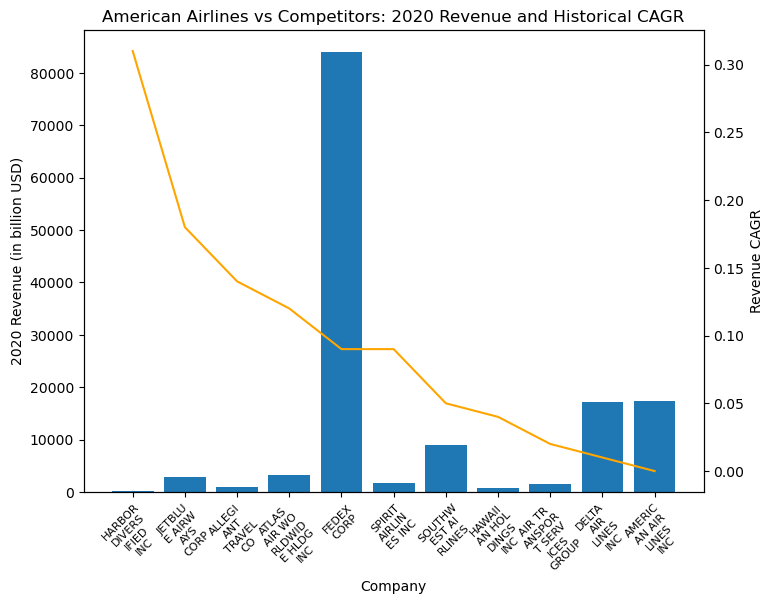

In [ ]:
# plot 2020 revenue and historical cagr

import textwrap

competitor_rev_combined = competitor_cagr_df.merge(rev_2020, left_on = "company", right_on = "conm", how = "inner")
competitor_rev_combined

# Create a figure and a primary axis object
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot the bar chart on the primary axes
ax1.bar(competitor_rev_combined['company'], competitor_rev_combined['sale'])
ax1.set_xlabel('Company')
ax1.set_ylabel('2020 Revenue (in million USD)')

# Wrap each label at 6 characters
wrapped_labels = [textwrap.fill(label,6) for label in competitor_rev_combined['company']]

# Apply wrapped labels using plt.xticks()
plt.xticks(ticks=range(len(competitor_rev_combined['company'])), labels=wrapped_labels, rotation=45, fontsize = 8)

# Create a secondary axis object 
ax2 = ax1.twinx()

# Plot the line chart on the secondary axes
ax2.plot(competitor_rev_combined['company'], competitor_rev_combined['cagr'], color='orange')
ax2.set_ylabel('Revenue CAGR')

# Add title
plt.title('American Airlines vs Competitors: 2020 Revenue and Historical CAGR')
plt.show()


<b> Citation 1:</b>
- Name, version, company of AI tool: Chat GPT-5 mini.
- Chat objective: to learn how to create a line-bar chart with 2 axis
- Use of AI-generated content:  
    Evaluation of Results: ChatGPT correctly taught me how to create multiple-axis subplots, customize the primary and secondary axis (e.g., font size, rotation degree), and wrap text on x-axis. 
   
    Limitation: Its first suggestion on how to apply the text wrapping textwrap.wrap() did not live up to my expectation as the output text was still quite long and we needed to manually add a line breaker (\n). I then asked it for other ways and ChatGPT returned with quite useful ideas e.g., changing the font size or using another function called textwrap.fill() which breaks lines directly.  
  
    How I used the AI’s response: I used the AI’s guidance as a reference point to create a customized chart with my own data.
- URL of chat history: https://chatgpt.com/share/68e01fdf-c494-8009-a7a1-fb4f53788a67
- Time and date of chat: Oct 3 12pm

  
<b> Citation 2: </b>  

W3Schools. (2025). Pandas merge method. W3Schools.https://www.w3schools.com/python/pandas/ref_df_merge.asp

### <b>Profitability</b>

Here we will look at:  
- Latest ROA vs 2020 Airline Industry Benchmark to identify outperformers/ laggards
- ROA Trend overtime (i.e., average historical ROA)
- Latest Net income margin
- Net income margin trend (o.e., average NI margin)

In [199]:
# 2020 ROA

competitor_df = df[df["gvkey"].isin(company_code)]
roa_2020 = competitor_df[competitor_df['fyear'] == 2020].sort_values('roa', ascending=False)
roa_2020[['conm', 'roa']]

,conm,roa
124170,HARBOR DIVERSIFIED INC,0.113462
14369,FEDEX CORP,0.063194
119487,ATLAS AIR WORLDWIDE HLDG INC,0.059757
178946,AIR TRANSPORT SERVICES GROUP,0.010699
201501,SPIRIT AIRLINES INC,-0.051043
190505,ALLEGIANT TRAVEL CO,-0.056489
36248,SOUTHWEST AIRLINES,-0.088875
174886,JETBLUE AIRWAYS CORP,-0.101000
1442,AMERICAN AIRLINES INC,-0.122083
118091,HAWAIIAN HOLDINGS INC,-0.128439


<b> Citation </b>  
W3Schools. (2025). Pandas DataFrame isin() Method
https://www.w3schools.com/python/pandas/ref_df_isin.asp


In [200]:
# Select industry ROA benchmark

print("airlines median ROA 2020: " + str(company_data[company_data['fyear'] == 2020]['roa'].median()))   
print("airlines mean ROA 2020: " + str(company_data[company_data['fyear'] == 2020]['roa'].mean()))  

airlines median ROA 2020: -0.0783224215678328
airlines mean ROA 2020: -0.10630364787024049


In [201]:
# Historical average ROA

competitor_df.groupby('conm')['roa'].mean().sort_values(ascending=False)


conm
SPIRIT AIRLINES INC             0.104676
ALLEGIANT TRAVEL CO             0.082701
SOUTHWEST AIRLINES              0.051203
FEDEX CORP                      0.050814
ATLAS AIR WORLDWIDE HLDG INC    0.029895
JETBLUE AIRWAYS CORP            0.021583
AMERICAN AIRLINES INC          -0.010141
DELTA AIR LINES INC            -0.011284
AIR TRANSPORT SERVICES GROUP   -0.027134
HARBOR DIVERSIFIED INC         -0.475981
HAWAIIAN HOLDINGS INC          -0.851615
Name: roa, dtype: float64

In [202]:
# Net income margin in 2020

competitor_df['ni_margin'] = competitor_df['ni'] / competitor_df['sale']
ni_margin_2020 = competitor_df[competitor_df['fyear'] == 2020].sort_values('ni_margin', ascending=False)
ni_margin_2020[['conm', 'ni_margin']]

/var/folders/by/1lcwr0rd5l986kjgfbpvxtqc0000gn/T/ipykernel_33227/1425592933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  competitor_df['ni_margin'] = competitor_df['ni'] / competitor_df['sale']


,conm,ni_margin
124170,HARBOR DIVERSIFIED INC,0.213838
119487,ATLAS AIR WORLDWIDE HLDG INC,0.112200
14369,FEDEX CORP,0.062304
178946,AIR TRANSPORT SERVICES GROUP,0.020448
190505,ALLEGIANT TRAVEL CO,-0.185939
201501,SPIRIT AIRLINES INC,-0.236848
36248,SOUTHWEST AIRLINES,-0.339744
174886,JETBLUE AIRWAYS CORP,-0.457897
1442,AMERICAN AIRLINES INC,-0.487453
118091,HAWAIIAN HOLDINGS INC,-0.604791


In [204]:
# Historical average net income margin

competitor_df.groupby('conm')['ni_margin'].mean().sort_values(ascending=False)

#Note: Harbor Diversified Inc and Hawaiian Holdings Inc have infinite margin records due to multiple years with zero-reported sales.

conm
ALLEGIANT TRAVEL CO             0.081605
SPIRIT AIRLINES INC             0.075687
SOUTHWEST AIRLINES              0.055137
ATLAS AIR WORLDWIDE HLDG INC    0.054185
FEDEX CORP                      0.036902
JETBLUE AIRWAYS CORP            0.015482
AIR TRANSPORT SERVICES GROUP    0.010712
AMERICAN AIRLINES INC          -0.025435
DELTA AIR LINES INC            -0.041907
HARBOR DIVERSIFIED INC              -inf
HAWAIIAN HOLDINGS INC               -inf
Name: ni_margin, dtype: float64

### <b>Market share</b>
  
Here we will look at:
- The latest available snapshot of American Airlines and competitors' marketshares.  
- Trend overtime (i.e., percent point change from first to last year of data available)

In [172]:
#2020 Market share

# we define it as Firm's Sales / Total Sales of all Air Transportation industry

company_data_2020 = company_data[company_data['fyear'] == 2020]
company_data_2020['market_share'] = company_data_2020['sale'] / (company_data_2020['sale'].sum()) * 100

competitor_share_2020 = company_data_2020[company_data_2020["gvkey"].isin(company_code)].sort_values('market_share', ascending=False)
competitor_share_2020[['conm', 'market_share']]


/var/folders/by/1lcwr0rd5l986kjgfbpvxtqc0000gn/T/ipykernel_33227/3084196314.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  company_data_2020['market_share'] = company_data_2020['sale'] / (company_data_2020['sale'].sum()) * 100


,conm,market_share
14369,FEDEX CORP,30.627201
1442,AMERICAN AIRLINES INC,6.323593
11302,DELTA AIR LINES INC,6.236044
36248,SOUTHWEST AIRLINES,3.300598
119487,ATLAS AIR WORLDWIDE HLDG INC,1.171375
174886,JETBLUE AIRWAYS CORP,1.078677
201501,SPIRIT AIRLINES INC,0.660274
178946,AIR TRANSPORT SERVICES GROUP,0.572926
190505,ALLEGIANT TRAVEL CO,0.361166
118091,HAWAIIAN HOLDINGS INC,0.308177


<b> Citation </b>  
W3Schools. (2025). Pandas DataFrame isin() Method
https://www.w3schools.com/python/pandas/ref_df_isin.asp

In [205]:
# historical market share percent change

market_share_change = {'company': [], 'market_share_percent_point_change': [], 'duration' : []}

for name, data in competitor_df.groupby('conm'):
    data = data.sort_values('fyear')

    # get start year market share = start year sales / total sales of all same-industry firms in that year
    start_year = data.iloc[0]['fyear']
    start_share = (data.iloc[0]['sale'] / company_data[company_data['fyear'] == start_year]['sale'].sum()) * 100

    # get end year sales 
    end_year = data.iloc[-1]['fyear']
    end_share = (data.iloc[-1]['sale'] / company_data[company_data['fyear'] == end_year]['sale'].sum()) * 100 

    # calculate duration    
    duration = data.iloc[-1]['fyear'] - data.iloc[0]['fyear']  

    #c calculate market share percent point change
    share_change = round(end_share - start_share, 5) 

    #append results to dictionary  
    market_share_change['company'].append(name)
    market_share_change['market_share_percent_point_change'].append(share_change)
    market_share_change['duration'].append(duration)

competitor_market_share_df = pd.DataFrame(market_share_change, columns=['company', 'market_share_percent_point_change', 'duration']).sort_values('market_share_percent_point_change', ascending=False)
competitor_market_share_df


,company,market_share_percent_point_change,duration
5,FEDEX CORP,9.20237,26
9,SOUTHWEST AIRLINES,1.56630,25
3,ATLAS AIR WORLDWIDE HLDG INC,1.06798,25
8,JETBLUE AIRWAYS CORP,1.03179,20
10,SPIRIT AIRLINES INC,0.44545,11
1,ALLEGIANT TRAVEL CO,0.31812,15
7,HAWAIIAN HOLDINGS INC,0.09875,25
6,HARBOR DIVERSIFIED INC,0.06770,25
0,AIR TRANSPORT SERVICES GROUP,0.05181,19
4,DELTA AIR LINES INC,-1.12556,25


### 3C. Specific analysis of the chosen firm
  
Perform an analysis of the historical stock prices, ROA, revenue, and assets of the chosen firm. Investigate potential correlations and address noteworthy decreases and increases.


### Note on stock price analysis
  
- Since our company of interest, American Airlines Inc (gvkey=1388) does not have any historical stock price data, we will use the stock price data of American Airlines Group Inc (gvkey: 1045) for the analysis.  
  
- This could be due to the fact that American Airlines Group Inc is the public parent holding company of American Airline Inc.  
Also, in 2013, American Airline merged with US Airway and thus formed American Airline Group Inc., which has been listed with 'AAL' ticker ever since.  
Source: https://americanairlines.gcs-web.com/#:~:text=American%20Airlines%20Group%20Inc.,under%20the%20ticker%20symbol%20AAL.

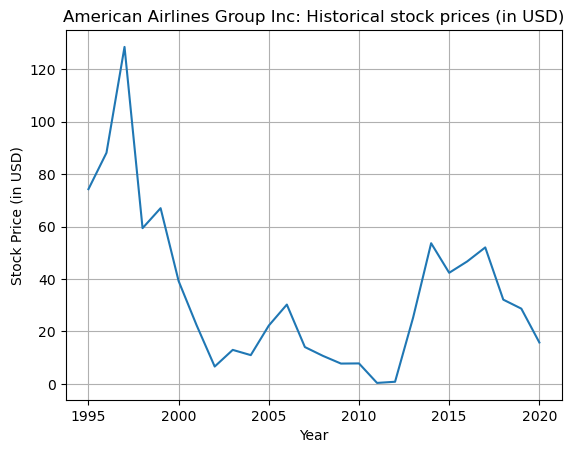

In [158]:
#historical stock prices

american_group_data = company_data[company_data['conm'] == "AMERICAN AIRLINES GROUP INC"]

astock = american_group_data[['prcc_c', 'fyear']]
plt.plot(astock.fyear, astock.prcc_c)
plt.grid(True)

plt.title('American Airlines Group Inc: Historical stock prices (in USD)')
plt.xlabel('Year')
plt.ylabel('Stock Price (in USD)')

plt.show()


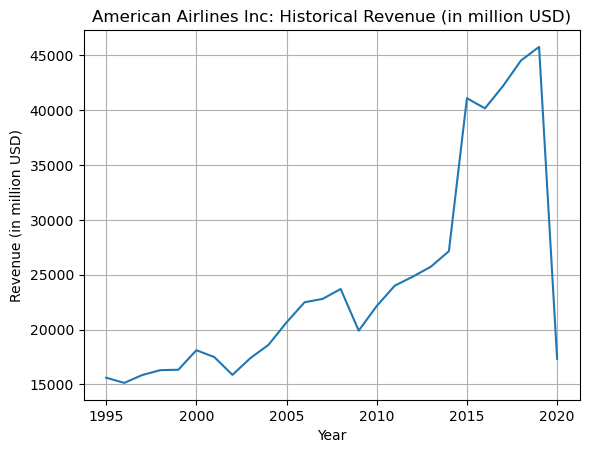

In [207]:
#historical revenue

american_data = company_data[company_data['conm'] == "AMERICAN AIRLINES INC"]
asale = american_data[['sale', 'fyear']]
plt.plot(asale.fyear, asale.sale)
plt.grid(True)

plt.title('American Airlines Inc: Historical Revenue (in million USD)')
plt.xlabel('Year')
plt.ylabel('Revenue (in million USD)')

plt.show()

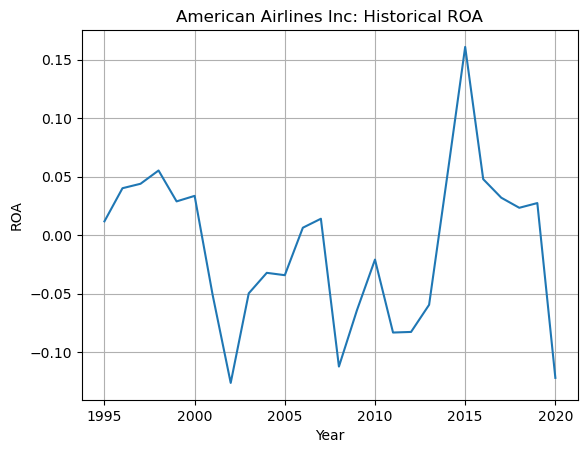

In [152]:
#historical ROA

american_data = company_data[company_data['conm'] == "AMERICAN AIRLINES INC"]
aroa = american_data[['roa', 'fyear']]
plt.plot(aroa.fyear, aroa.roa)
plt.grid(True)

plt.title('American Airlines Inc: Historical ROA')
plt.xlabel('Year')
plt.ylabel('ROA')

plt.show()

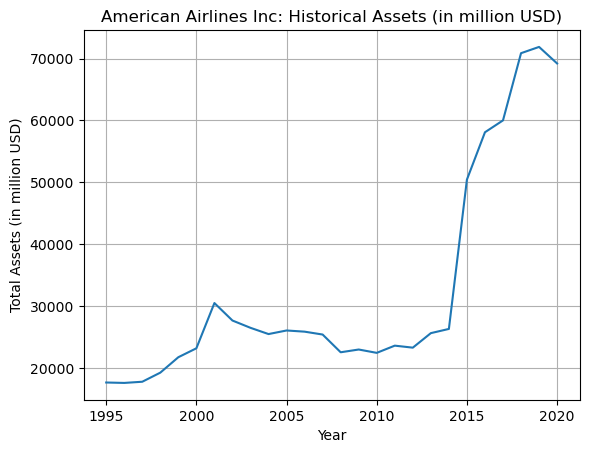

In [206]:
#historical assets

aasset = american_data[['asset', 'fyear']]
plt.plot(aasset.fyear, aasset.asset)
plt.grid(True)

plt.title('American Airlines Inc: Historical Assets (in million USD)')
plt.xlabel('Year')
plt.ylabel('Total Assets (in million USD)')

plt.show()

/var/folders/by/1lcwr0rd5l986kjgfbpvxtqc0000gn/T/ipykernel_33227/198372832.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anim['ni_margin'] = american_data['ni'] / american_data['sale']


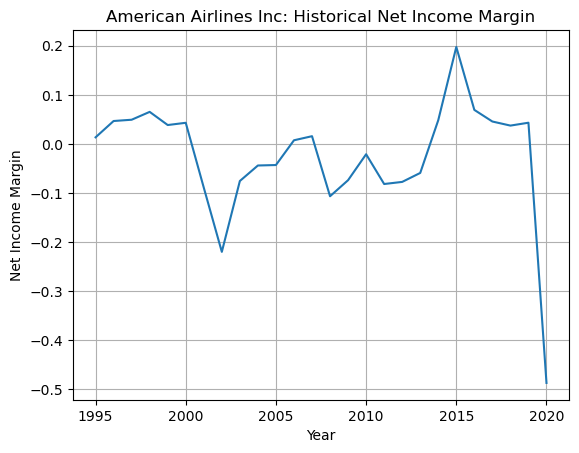

In [ ]:
#historical net income margin

anim = american_data[['asset', 'fyear']]
anim['ni_margin'] = american_data['ni'] / american_data['sale']
plt.plot(anim.fyear, anim.ni_margin)
plt.grid(True)

plt.title('American Airlines Inc: Historical Net Income Margin')
plt.xlabel('Year')
plt.ylabel('Net Income Margin')

plt.show()

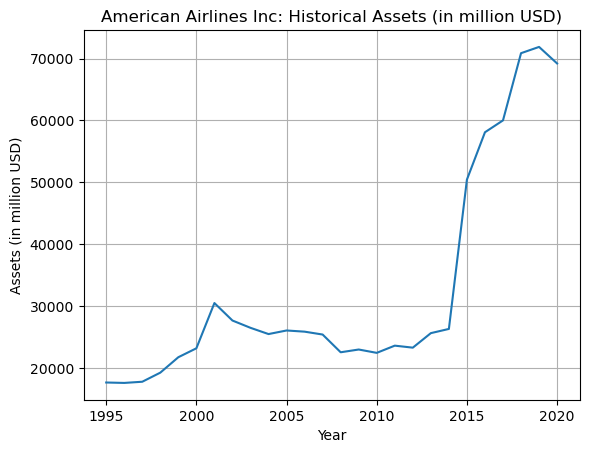

In [209]:
#historical assets

astock = american_data[['asset', 'fyear']]
plt.plot(astock.fyear, astock.asset)
plt.grid(True)

plt.title('American Airlines Inc: Historical Assets (in million USD)')
plt.xlabel('Year')
plt.ylabel('Assets (in million USD)')

plt.show()

### End.